In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv('https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


#### What is say us data ?
##### In here there is 303 row, 14 column
##### we know first 2 column 
##### cp = Chest pain type /0 = not pain / 3 = very pain
##### trestbps = Resting blood pressure 
##### chol = Cholesterol
##### fbs = Fasting Blood Sugar
##### restecg = Resting ECG
##### thalach = Max heart rate
##### exang = Exercise angina
##### oldpeak = ST depression in ECG
##### slope = ST slope
##### ca = Major vessels
##### thal = Thalassemia type
##### target : 1 = has heart disease / 0 = no heart disease 

In [49]:
print(df.shape)
print(df.head())

(303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [50]:
# Not NAN values, it's good
# --------------------------------------
# Some columns are categorical, meaning they are written as numbers, but they actually represent distinct groups. 
# Since there is no mathematical relationship between them, we use One-Hot Encoding to help the model understand them correctly.  
# For example - 'cp' is ordinal but 'thal','restecg','slope' is nominal and we will One-Hot the nominals.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [51]:
# we can say that it is middle-aged people who participate more in experiments ,cause most patients are between the ages of 47-61
# ---------------------------------
# Blood pressure:
#  Normal: < 120/80
#  Elevated: 120–129 / <80
#  High blood pressure: ≥130/80
# min 94 is too low, this patient may be in shock or there may be an error in the measurement
# std 17.53 - values are widespread
# 25% and 75% - this is the pre-hypertensive zone
# max 200 - hypertension
# ----------------------------------
# mean 246 it's highly
# std 51.83 - cholesterol values are widespread
# 25% and 75% - is highly in this zones 
# max 564 - anormal level
# ---------------------------------
# ca - 50% of patients had no vascular problems

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


<Axes: xlabel='target', ylabel='age'>

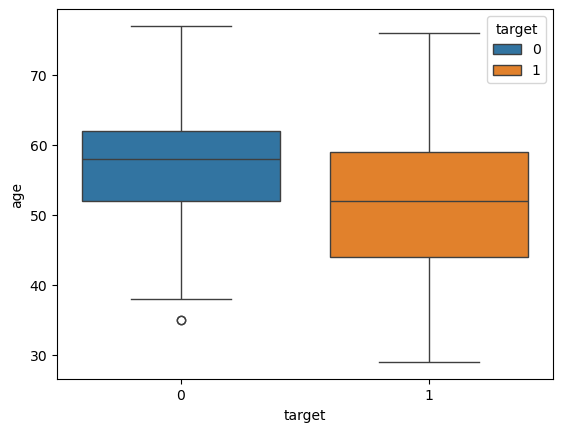

In [52]:
# Most people with heart disease are between the ages of 42 and 60. 
sns.boxplot(data = df, x = 'target', y = 'age',hue = 'target')

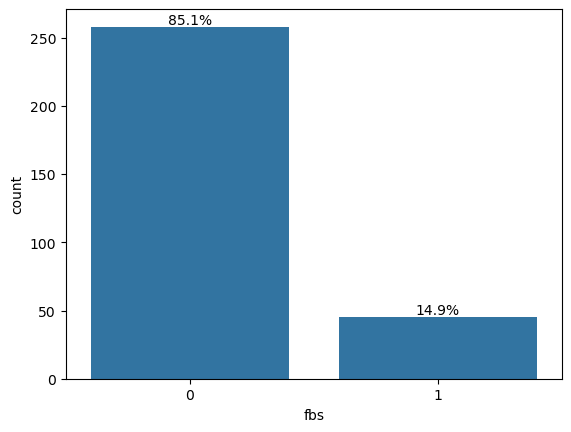

In [53]:
# 85% of patients (258 people) → normal blood sugar (0)
# Only 15% (45 people) → high blood sugar (1)

ax = sns.countplot(data=df, x='fbs')
total = len(df)

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom')

plt.show()

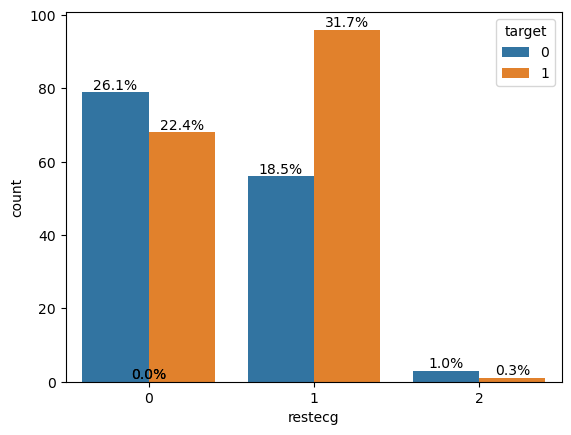

In [54]:
# Patients with an anormal ECG (1) have a higher incidence of heart disease (31.7% vs. 18.5%). This suggests that restECG is an important feature.
# But a normal ECG result does not mean that the patient is not sick. The ECG alone is not enough, it must be considered in conjunction with other factors.

ax = sns.countplot(data=df, x='restecg', hue = 'target')
total = len(df)

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom')

plt.show()

<Axes: xlabel='thalach', ylabel='Count'>

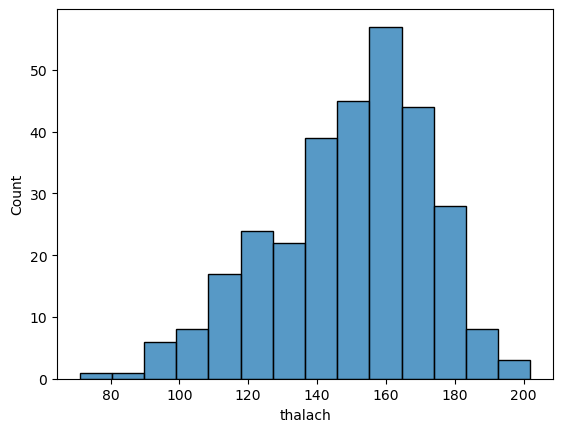

In [55]:
sns.histplot(data = df, x = 'thalach')

In [56]:
# 207 person is men, others women but we have to check
df['sex'].value_counts()

sex
1    207
0     96
Name: count, dtype: int64

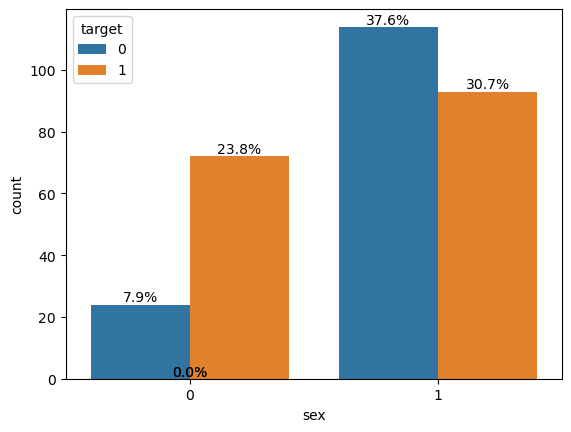

In [57]:
# Most people with heart problems are men, but women are slightly less likely to have them,
ax = sns.countplot(data=df, x='sex', hue = 'target')
total = len(df)

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom')

plt.show()

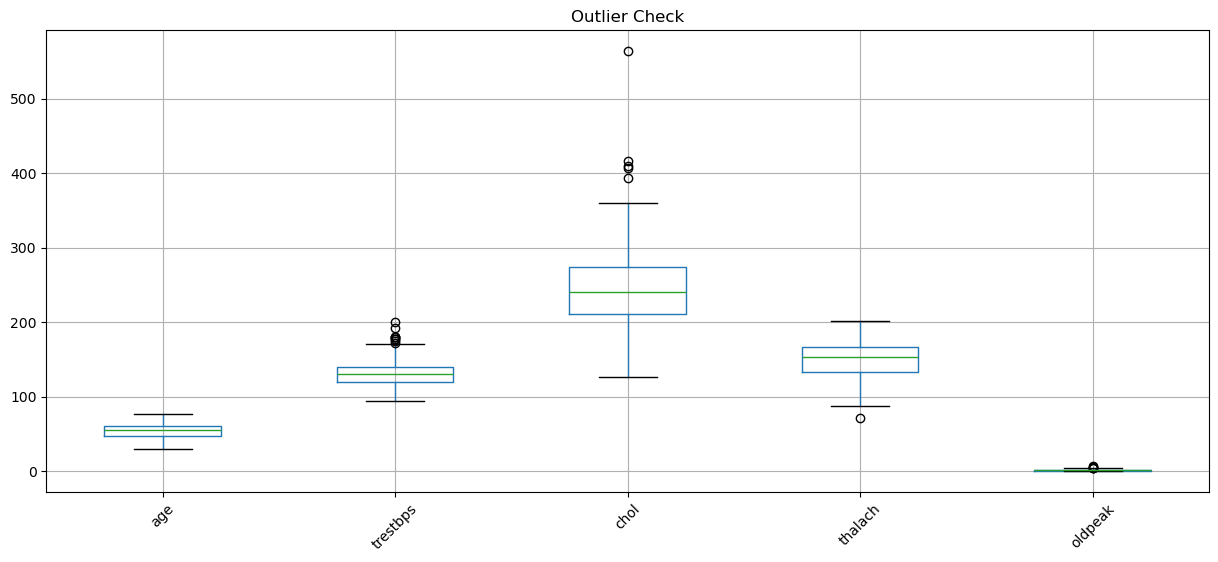

In [58]:
plt.figure(figsize=(15, 6))
df[["age", "trestbps", "chol", "thalach", "oldpeak"]].boxplot()
plt.title("Outlier Check")
plt.xticks(rotation=45)
plt.show()

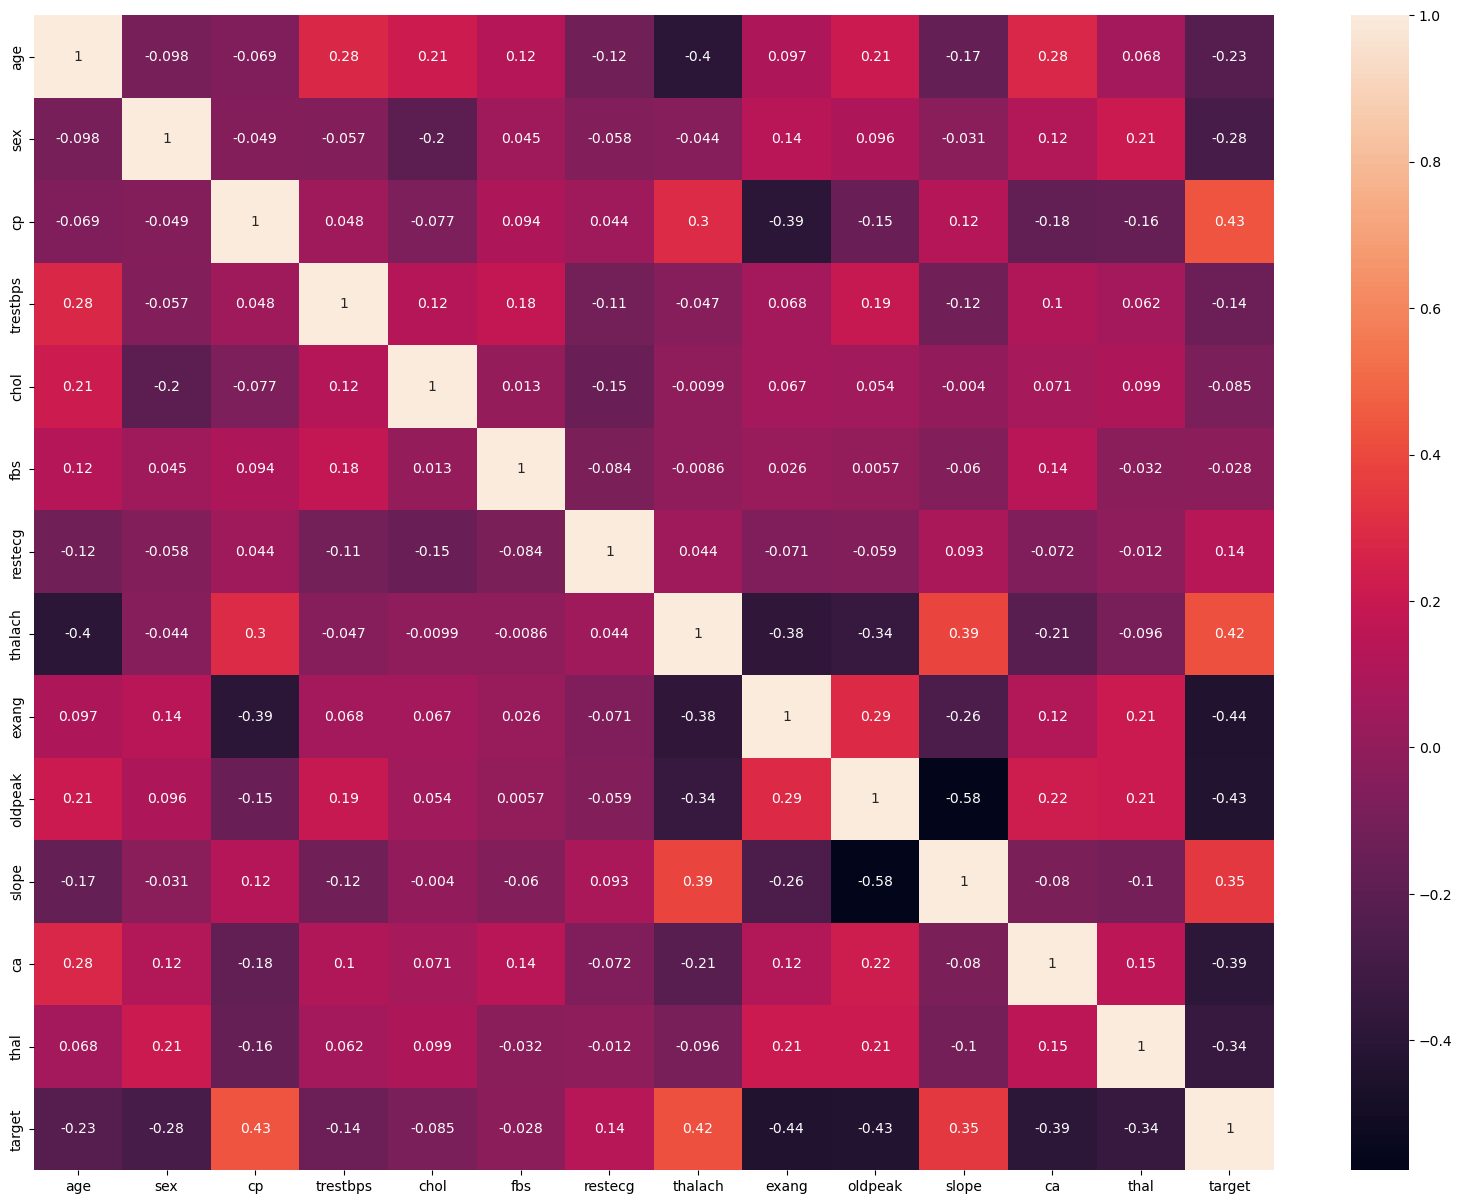

In [59]:
# positive correlation columns :cp, thalach, slope
# negative correlation cols: exang, oldpeak, ca, thal
# People with chest pain and increased heart rate are more prone to heart disease
# Since there is a negative relationship in others, as the indicators or categories in those columns increase, there are people without heart disease,
# but this cannot always be said to be the case, we come to this conclusion simply because this dataset consists of 303 people

plt.figure(figsize =(20,15))
sns.heatmap(df.corr(),annot = True)
plt.show()

### Hipothesis Tests

In [60]:
from scipy import stats

In [61]:
# Patients are on average 4 years younger than healthy people. This is a small but statistically significant difference
healthy = df[df['target'] == 0]['age']
diseased = df[df['target'] == 1]['age']

t_stat, p_value = stats.ttest_ind(healthy, diseased)
print(f'Healthy {healthy.mean():.1f}\nDiseased : {diseased.mean():.1f}\np-value: {p_value:.4f}')

Healthy 56.6
Diseased : 52.5
p-value: 0.0001


In [62]:
# There is a real connect between sex and heart disease
chi2, p_value_chi, _, _ = stats.chi2_contingency(pd.crosstab(df['sex'], df['target']))
print(f'P-value : {p_value_chi:.4f}')

P-value : 0.0000


### Feature Engineering

In [63]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [64]:
# Let's use a formula from medicine. 220 - age = max heart rate
df['thalach_ratio'] = df['thalach'] / (220 - df['age'])

In [65]:
#from statsmodels.stats.outliers_influence import variance_inflation_factor
#
#X_vif = df.drop(columns = ['target'])
#
#vif_data = pd.DataFrame()
#vif_data['Feature'] = X_vif.columns
#vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i)
#                   for i in range(X_vif.shape[1])]
#print(vif_data.sort_values('VIF', ascending = False))

In [66]:
df = pd.get_dummies(df, columns = ['slope', 'thal', 'restecg'], drop_first =True)


In [67]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
num_col = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak','thalach_ratio']

df[num_col] = scaler.fit_transform(df[num_col])

In [68]:
df

,age,sex,cp,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,thalach_ratio,slope_1,slope_2,thal_1,thal_2,thal_3,restecg_1,restecg_2
0,0.592593,1,3,0.75,-0.110236,1,-0.092308,0,0.9375,0,1,0.160557,False,False,True,False,False,False,False
1,-1.333333,1,2,0.00,0.157480,0,1.046154,0,1.6875,0,1,0.557986,False,False,False,True,False,True,False
2,-1.037037,0,1,0.00,-0.566929,0,0.584615,0,0.3750,0,1,0.193334,False,True,False,True,False,False,False
3,0.074074,1,1,-0.50,-0.062992,0,0.769231,0,0.0000,0,1,0.937854,False,True,False,True,False,True,False
4,0.148148,0,0,-0.50,1.795276,0,0.307692,1,-0.1250,0,1,0.427245,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.148148,0,0,0.50,0.015748,0,-0.923077,1,-0.3750,0,0,-1.040590,True,False,False,False,True,True,False
299,-0.740741,1,3,-1.00,0.377953,0,-0.646154,0,0.2500,0,0,-1.042477,True,False,False,False,True,True,False
300,0.962963,1,0,0.70,-0.740157,1,-0.369231,0,1.6250,2,0,-0.005622,True,False,False,False,True,True,False
301,0.148148,1,0,0.00,-1.716535,0,-1.169231,1,0.2500,1,0,-1.334156,True,False,False,False,True,True,False


In [82]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(272, 18)
(31, 18)
(272,)
(31,)


In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

ln_model = LogisticRegression(random_state = 42)
ln_model.fit(X_train, y_train)
y_pred = ln_model.predict(X_test)

print('Train acc:', ln_model.score(X_train, y_train))
print('Test acc:', ln_model.score(X_test, y_test))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Train acc: 0.8713235294117647
Test acc: 0.8387096774193549
              precision    recall  f1-score   support

           0       0.85      0.79      0.81        14
           1       0.83      0.88      0.86        17

    accuracy                           0.84        31
   macro avg       0.84      0.83      0.84        31
weighted avg       0.84      0.84      0.84        31

[[11  3]
 [ 2 15]]


In [84]:
for c in [0.03, 0.05, 0.07, 0.09, 0.1, 0.3, 0.5, 0.7, 0.9]:
    model = LogisticRegression(max_iter=1000, C=c, random_state=42)
    model.fit(X_train, y_train)
    print(f"C={c}, Train: {model.score(X_train, y_train):.4f}, Test: {model.score(X_test, y_test):.4f}")

C=0.03, Train: 0.8676, Test: 0.8065
C=0.05, Train: 0.8713, Test: 0.8065
C=0.07, Train: 0.8713, Test: 0.8065
C=0.09, Train: 0.8750, Test: 0.8065
C=0.1, Train: 0.8750, Test: 0.8065
C=0.3, Train: 0.8787, Test: 0.8065
C=0.5, Train: 0.8787, Test: 0.8065
C=0.7, Train: 0.8713, Test: 0.8065
C=0.9, Train: 0.8713, Test: 0.8387


In [85]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(ln_model, X_train, y_train, cv=5)
print(scores.mean())
print(scores.std())

0.838114478114478
0.038148846505208035


### Here, we obtained a satisfactory model result by using only one model, but since this data is very small, it is not possible to make a definitive decision. Instead, we can multiply the data and check with it.